# 06 · D1 ESCO + D2 `data_jobs` — the skill vocabulary

§4.5 needs a controlled vocabulary with aliases, and a hard-vs-preferred requirement
distinction. ESCO supplies both. The open question is **coverage**: ESCO is an EU
labour-market taxonomy, and this project matches software/data roles.

This notebook measures that coverage instead of assuming it.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from candidate_screener.config import DOCS_DATA, RAW, MANIFEST, PROFILE_METRICS
from candidate_screener.data.profile import load_split, skill_frequencies
from candidate_screener.data.sources import SOURCES

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

METRICS = json.loads(PROFILE_METRICS.read_text())["checks"]
print("profile metrics generated:", json.loads(PROFILE_METRICS.read_text())["generated"])

profile metrics generated: 2026-08-19T11:49:47+00:00


In [2]:
esco_dir = RAW / "esco_dataset-v1.2.1-classification"
skills = pd.read_csv(esco_dir / "skills_en.csv", low_memory=False)
rel = pd.read_csv(esco_dir / "occupationSkillRelations_en.csv", low_memory=False)
print(f"{len(skills):,} skills   {len(rel):,} occupation-skill links")
print(skills.skillType.value_counts().to_dict())
skills[["preferredLabel", "skillType", "reuseLevel", "altLabels"]].head(3)

13,960 skills   126,051 occupation-skill links
{'skill/competence': 10734, 'knowledge': 3221}


,preferredLabel,skillType,reuseLevel,altLabels
0,manage musical staff,skill/competence,sector-specific,manage music staff\ncoordinate duties of musical staff\ndirect musical staff\nmanage s...
1,supervise correctional procedures,skill/competence,occupation-specific,manage prison procedures\nmonitor correctional procedures\noversee prison procedures\n...
2,apply anti-oppressive practices,skill/competence,sector-specific,make use of anti-oppressive practices\nuse anti-oppressive practices\napply non-oppres...


## Aliases — the inventory that makes normalisation possible

~86,694 alternative labels; median 6 per skill, 18 skills with none


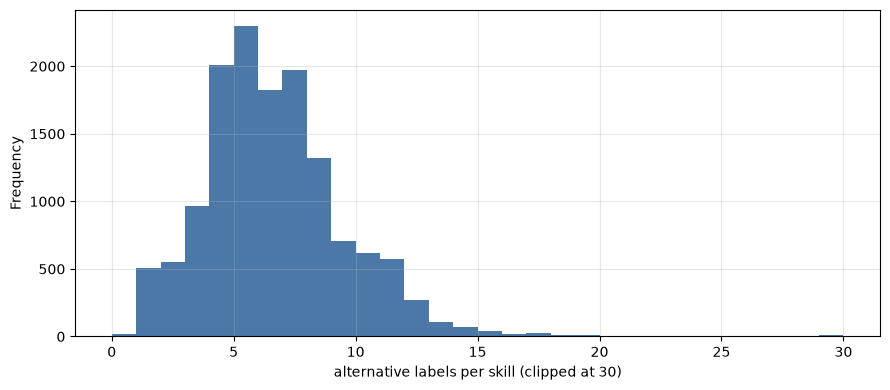

In [3]:
alias_n = skills.altLabels.fillna("").str.count("\n").add(1).where(skills.altLabels.notna(), 0)
print(f"~{int(alias_n.sum()):,} alternative labels; median {alias_n.median():.0f} per skill, "
      f"{(alias_n == 0).sum():,} skills with none")
ax = alias_n.clip(upper=30).plot.hist(bins=30, color="#4C78A8")
ax.set_xlabel("alternative labels per skill (clipped at 30)"); plt.tight_layout()

## Hard vs preferred requirements come free with the taxonomy

In [4]:
print(rel.relationType.value_counts().to_dict())
print("\nexample — essential vs optional skills for one occupation:")
occ = rel.occupationUri.value_counts().index[0]
ex = rel[rel.occupationUri == occ].merge(
    skills[["conceptUri", "preferredLabel"]], left_on="skillUri", right_on="conceptUri")
ex.groupby("relationType").preferredLabel.apply(lambda s: list(s[:5]))

{'essential': 67600, 'optional': 58451}

example — essential vs optional skills for one occupation:


relationType
essential          [neoplasia, electroencephalography, dermapathology, urogynaecology, urogynaecology]
optional     [renal diseases, microbiology-bacteriology, neurological surgery, occupational medicin...
Name: preferredLabel, dtype: object

67,600 `essential` and 58,451 `optional` links. §4.5's hard-requirement check does not need
to be invented — it is `relationType == "essential"` for the matched occupation.

## Coverage test — does ESCO know the skills tech job postings actually ask for?

In [5]:
jobs = load_split("data-jobs", "train")
freq = skill_frequencies(jobs)   # job_skills ships as a stringified list -- parse, do not iterate
top = pd.DataFrame(freq.most_common(100), columns=["skill", "postings"])
print(f"{len(freq)} distinct skills over {len(jobs):,} postings")
top.head(15)


252 distinct skills over 785,741 postings


,skill,postings
0,sql,384849
1,python,380909
2,aws,145381
3,azure,132527
4,r,130892
5,tableau,127213
6,excel,127018
7,spark,114609
8,power bi,98147
9,java,85612


In [6]:
import re

vocab = set(skills.preferredLabel.str.lower().dropna())
for cell in skills.altLabels.dropna():
    vocab.update(a.strip().lower() for a in str(cell).split("\n") if a.strip())
words = {w for v in vocab for w in re.findall(r"[a-z0-9+#.]+", v)}
print(f"ESCO surface forms (preferred + alt): {len(vocab):,}")

tokens = lambda s: re.findall(r"[a-z0-9+#.]+", s.lower())
top["exact"] = top.skill.str.lower().isin(vocab)
top["relaxed"] = top.skill.str.lower().apply(
    lambda s: s in vocab or all(w in words for w in tokens(s)))

weighted = lambda col: top.loc[top[col], "postings"].sum() / top.postings.sum()
print(f"\ntop-100 tech skills present in ESCO")
print(f"  exact label match  : {top.exact.sum():3d}/100   ({weighted('exact'):.0%} of posting volume)")
print(f"  relaxed word match : {top.relaxed.sum():3d}/100   ({weighted('relaxed'):.0%} of posting volume)")
print("\nabsent even under relaxed matching:")
print(", ".join(top.loc[~top.relaxed, "skill"].head(30)))


ESCO surface forms (preferred + alt): 99,624



top-100 tech skills present in ESCO
  exact label match  :  33/100   (47% of posting volume)
  relaxed word match :  55/100   (66% of posting volume)

absent even under relaxed matching:
aws, azure, tableau, snowflake, databricks, gcp, kafka, docker, kubernetes, mongodb, redshift, pyspark, pandas, pytorch, bigquery, jira, numpy, terraform, scikit-learn, looker, github, qlik, vba, cassandra, alteryx, unix, spss, elasticsearch, gitlab, jupyter


This is the measured basis for the D1 caveat. The misses are overwhelmingly **concrete tools
and products** — exactly the terms a technical recruiter screens on — while ESCO carries the
abstract competences. Neither source is sufficient alone.

**Consequence for action plan §3.5:** `data/vocab/skills.csv` is ESCO preferred labels +
aliases, **left-joined with the `data_jobs` frequency counts**, with unmatched
high-frequency tool names added as project-local vocabulary entries carrying a
`source = data_jobs` provenance flag. Frequency also gives the weighting that lets a match on
`pytorch` count for more than a match on a generic competence.

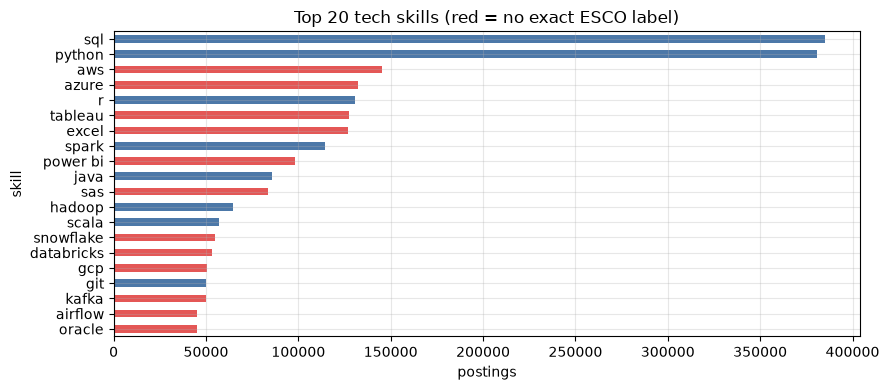

In [7]:
head = top.head(20).sort_values("postings")
ax = head.set_index("skill").postings.plot.barh(
    color=["#4C78A8" if v else "#E45756" for v in head.exact])
ax.set_xlabel("postings"); ax.set_title("Top 20 tech skills (red = no exact ESCO label)")
plt.tight_layout()


Building the vocabulary itself is **Phase 3.5** and out of scope for the acquisition phase —
this notebook establishes only that both inputs are present, joinable, and individually
insufficient.